### Cleaning: fill the missing values with the training medians
Median, because the columns are skewed, and from the training set only; variant B without Insulin and SkinThickness, because 47 % and 29 % of their values are filled in.

In [ ]:
TRAIN_MEDIANS = df_train[ZERO_MEANS_MISSING].median()
TRAIN_MEDIANS

Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.4
dtype: float64

In [ ]:
def apply_cleaning(data, medians):
    """Same cleaning for train and test: fill the NaNs from 0 → NaN with the given (training) medians."""
    cleaned = data.copy()
    cleaned[ZERO_MEANS_MISSING] = cleaned[ZERO_MEANS_MISSING].fillna(medians)
    return cleaned


df_train_clean = apply_cleaning(df_train, TRAIN_MEDIANS)

assert df_train_clean.isna().sum().sum() == 0, "there are still NaNs in the training set"
assert list(df_train_clean.columns) == list(df_train.columns)
print("NaNs left in df_train_clean:", df_train_clean.isna().sum().sum())
print("Rows with the median filled in, per column:")
df_train[ZERO_MEANS_MISSING].isna().sum()

NaNs left in df_train_clean: 0
Rows with the median filled in, per column:


Glucose            4
BloodPressure     23
SkinThickness    175
Insulin          290
BMI                9
dtype: int64

**What we see:** training medians Glucose 117, BloodPressure 72, SkinThickness 29, Insulin 125, BMI 32.4; no NaN left.

## Step 5: Features, target and two baselines
Random baseline, glucose rule and "everyone has diabetes" as a reference; the glucose cut-off is chosen like the model's threshold: highest F2 with precision ≥ `P_MIN`.

In [95]:
TARGET = "Outcome"
FEATURES_WITHOUT_INSULIN_SKIN = [col for col in FEATURES if col not in ["Insulin", "SkinThickness"]]

X_train = df_train_clean[FEATURES]
y_train = df_train_clean[TARGET]
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("Features of variant B (without Insulin and SkinThickness):", FEATURES_WITHOUT_INSULIN_SKIN)

X_train: (614, 8) | y_train: (614,)
Features of variant B (without Insulin and SkinThickness): ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']


One scoring function for every model: F2, precision, recall, accuracy and whether precision ≥ `P_MIN`.

In [96]:
def classification_scores(y_true, y_pred):
    """The scores we report for every model: F2 (main metric), precision, recall, accuracy."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    return {
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision,
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "meets P_min": precision >= P_MIN,
    }


train_results = {}  # model name -> training scores, filled step by step

### 5.1 Random baseline

In [97]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
train_results["random baseline"] = classification_scores(y_train, dummy.predict(X_train))

train_results["reference: everyone has diabetes"] = classification_scores(y_train, np.ones(len(y_train), dtype=int))

pd.DataFrame.from_dict(train_results, orient="index").round(3)

,F2,precision,recall,accuracy,meets P_min
random baseline,0.342,0.344,0.341,0.544,False
reference: everyone has diabetes,0.728,0.349,1.000,0.349,False


**What we see:** random F2 0.34; "everyone has diabetes" reaches F2 0.73 but only precision 0.35, which is why we need `P_MIN`.

### 5.2 Rule-based baseline: glucose cutoff
Try every glucose value as cut-off, keep those with precision ≥ `P_MIN`, take the highest F2.

In [98]:
def rule_predict(data, cutoff):
    """Rule-based baseline: 1 (diabetes) if glucose is at or above the cutoff."""
    return (data["Glucose"] >= cutoff).astype(int)


cutoff_table = pd.DataFrame([
    {"cutoff": cutoff, **classification_scores(y_train, rule_predict(X_train, cutoff))}
    for cutoff in np.sort(X_train["Glucose"].unique())
])

allowed = cutoff_table[cutoff_table["meets P_min"]]
GLUCOSE_CUTOFF = allowed.loc[allowed["F2"].idxmax(), "cutoff"]
best_without_floor = cutoff_table.loc[cutoff_table["F2"].idxmax()]

print(f"Chosen cutoff (highest F2 with precision >= {P_MIN}): glucose >= {GLUCOSE_CUTOFF:.0f}")
print(f"Without the floor, F2 would pick glucose >= {best_without_floor['cutoff']:.0f} "
      f"(precision {best_without_floor['precision']:.2f})")

train_results[f"rule: glucose >= {GLUCOSE_CUTOFF:.0f}"] = classification_scores(y_train, rule_predict(X_train, GLUCOSE_CUTOFF))

Chosen cutoff (highest F2 with precision >= 0.5): glucose >= 112
Without the floor, F2 would pick glucose >= 100 (precision 0.44)


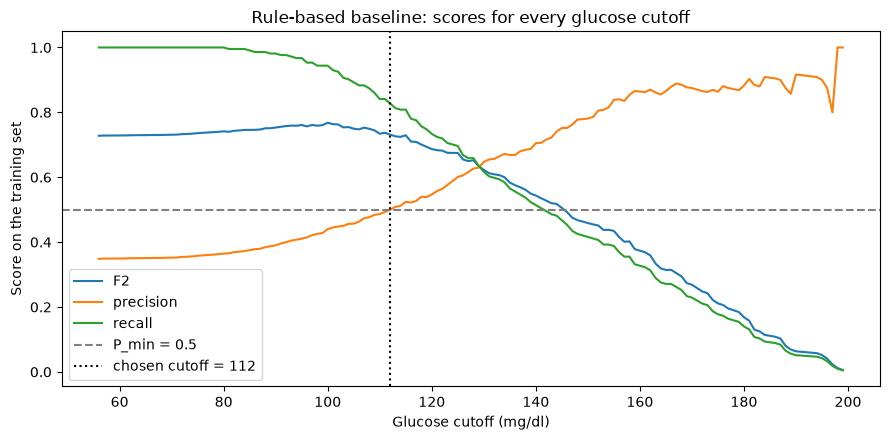

In [99]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for score in ["F2", "precision", "recall"]:
    ax.plot(cutoff_table["cutoff"], cutoff_table[score], label=score)
ax.axhline(P_MIN, color="grey", linestyle="--", label=f"P_min = {P_MIN}")
ax.axvline(GLUCOSE_CUTOFF, color="black", linestyle=":", label=f"chosen cutoff = {GLUCOSE_CUTOFF:.0f}")
ax.set_xlabel("Glucose cutoff (mg/dl)")
ax.set_ylabel("Score on the training set")
ax.set_title("Rule-based baseline: scores for every glucose cutoff")
ax.legend()
plt.tight_layout()
plt.show()

In [100]:
pd.DataFrame.from_dict(train_results, orient="index").round(3)

,F2,precision,recall,accuracy,meets P_min
random baseline,0.342,0.344,0.341,0.544,False
reference: everyone has diabetes,0.728,0.349,1.000,0.349,False
rule: glucose >= 112,0.731,0.500,0.827,0.651,True


**What we see:** cut-off 112 gives recall 0.83, precision 0.50, F2 0.73: the bar the model has to beat.

## Step 6: Logistic regression
`StandardScaler` fitted on train only; variant A with all 8 features, B without Insulin and SkinThickness; default threshold 0.5.

In [101]:
FEATURES_A = list(FEATURES)
FEATURES_B = FEATURES_WITHOUT_INSULIN_SKIN


def fit_logreg(features, class_weight=None):
    """Fit a StandardScaler on the training features, then a logistic regression on the scaled data."""
    scaler = StandardScaler().fit(df_train_clean[features])
    model = LogisticRegression(class_weight=class_weight)
    model.fit(scaler.transform(df_train_clean[features]), y_train)
    return scaler, model


def predict_probability(scaler, model, data, features):
    """Probability of diabetes (class 1) for every row of `data`."""
    return model.predict_proba(scaler.transform(data[features]))[:, 1]


scaler, logreg = fit_logreg(FEATURES_A)
scaler_b, logreg_b = fit_logreg(FEATURES_B)

# predict() uses the default threshold of 0.5
train_results["logreg A (all 8 features)"] = classification_scores(
    y_train, logreg.predict(scaler.transform(df_train_clean[FEATURES_A])))
train_results["logreg B (without Insulin, SkinThickness)"] = classification_scores(
    y_train, logreg_b.predict(scaler_b.transform(df_train_clean[FEATURES_B])))

pd.DataFrame.from_dict(train_results, orient="index").round(3)

,F2,precision,recall,accuracy,meets P_min
random baseline,0.342,0.344,0.341,0.544,False
reference: everyone has diabetes,0.728,0.349,1.000,0.349,False
rule: glucose >= 112,0.731,0.500,0.827,0.651,True
logreg A (all 8 features),0.622,0.770,0.593,0.796,True
"logreg B (without Insulin, SkinThickness)",0.617,0.764,0.589,0.793,True


**What we see:** F2 0.62, below the glucose rule (0.73) despite accuracy 0.80: at threshold 0.5 the model finds only 59 % of the cases; A ≈ B.

### 6.1 What did the model learn? The coefficients
Features are scaled, so coefficients are comparable; odds ratio = e^coefficient per standard deviation.

In [102]:
coefficients = pd.DataFrame({
    "coefficient A": pd.Series(logreg.coef_[0], index=FEATURES_A),
    "coefficient B": pd.Series(logreg_b.coef_[0], index=FEATURES_B),
})
coefficients["odds ratio A"] = np.exp(coefficients["coefficient A"])
coefficients.sort_values("coefficient A", ascending=False).round(2)

,coefficient A,coefficient B,odds ratio A
Glucose,1.18,1.16,3.26
BMI,0.69,0.69,1.99
Pregnancies,0.38,0.38,1.46
DiabetesPedigreeFunction,0.23,0.23,1.26
Age,0.15,0.15,1.16
SkinThickness,0.03,NaN,1.03
BloodPressure,-0.04,-0.04,0.96
Insulin,-0.07,NaN,0.94


**What we see:** Glucose dominates (odds ratio 3.3), then BMI and Pregnancies; Insulin ≈ 0, because its information is already in Glucose (ρ = 0.67).

## Step 7: Handle the class imbalance
`class_weight="balanced"` changes what the model learns, the threshold changes how probabilities become decisions.

### 7a. Class weights: `class_weight="balanced"`

In [103]:
scaler_balanced, logreg_balanced = fit_logreg(FEATURES_A, class_weight="balanced")
scaler_balanced_b, logreg_balanced_b = fit_logreg(FEATURES_B, class_weight="balanced")

train_results["logreg A balanced"] = classification_scores(
    y_train, logreg_balanced.predict(scaler_balanced.transform(df_train_clean[FEATURES_A])))
train_results["logreg B balanced"] = classification_scores(
    y_train, logreg_balanced_b.predict(scaler_balanced_b.transform(df_train_clean[FEATURES_B])))

pd.DataFrame.from_dict(train_results, orient="index").round(3)

,F2,precision,recall,accuracy,meets P_min
random baseline,0.342,0.344,0.341,0.544,False
reference: everyone has diabetes,0.728,0.349,1.000,0.349,False
rule: glucose >= 112,0.731,0.500,0.827,0.651,True
logreg A (all 8 features),0.622,0.770,0.593,0.796,True
"logreg B (without Insulin, SkinThickness)",0.617,0.764,0.589,0.793,True
logreg A balanced,0.695,0.639,0.710,0.759,True
logreg B balanced,0.701,0.648,0.715,0.765,True


**What we see:** `balanced` lifts recall to 0.71 and F2 to 0.70, still below the glucose rule.

### 7b. Choose the decision threshold
Per model on the training data: highest F2 with precision ≥ `P_MIN`.

In [104]:
def best_threshold(y_true, probability):
    """Highest F2 among the thresholds with precision >= P_MIN; also returns the scores of every threshold."""
    table = pd.DataFrame([
        {"threshold": t, **classification_scores(y_true, (probability >= t).astype(int))}
        for t in np.unique(probability)
    ])
    allowed = table[table["meets P_min"]]
    return allowed.loc[allowed["F2"].idxmax(), "threshold"], table


candidates = {
    "logreg A": (scaler, logreg, FEATURES_A),
    "logreg B": (scaler_b, logreg_b, FEATURES_B),
    "logreg A balanced": (scaler_balanced, logreg_balanced, FEATURES_A),
    "logreg B balanced": (scaler_balanced_b, logreg_balanced_b, FEATURES_B),
}

THRESHOLDS = {}         # model name -> chosen threshold, needed again in step 8
threshold_tables = {}   # model name -> scores for every threshold, for the plot
for name, (model_scaler, model, features) in candidates.items():
    probability = predict_probability(model_scaler, model, df_train_clean, features)
    THRESHOLDS[name], threshold_tables[name] = best_threshold(y_train, probability)
    train_results[f"{name} + threshold {THRESHOLDS[name]:.2f}"] = classification_scores(
        y_train, (probability >= THRESHOLDS[name]).astype(int))

pd.Series(THRESHOLDS, name="chosen threshold").round(3)

logreg A             0.187
logreg B             0.162
logreg A balanced    0.265
logreg B balanced    0.260
Name: chosen threshold, dtype: float64

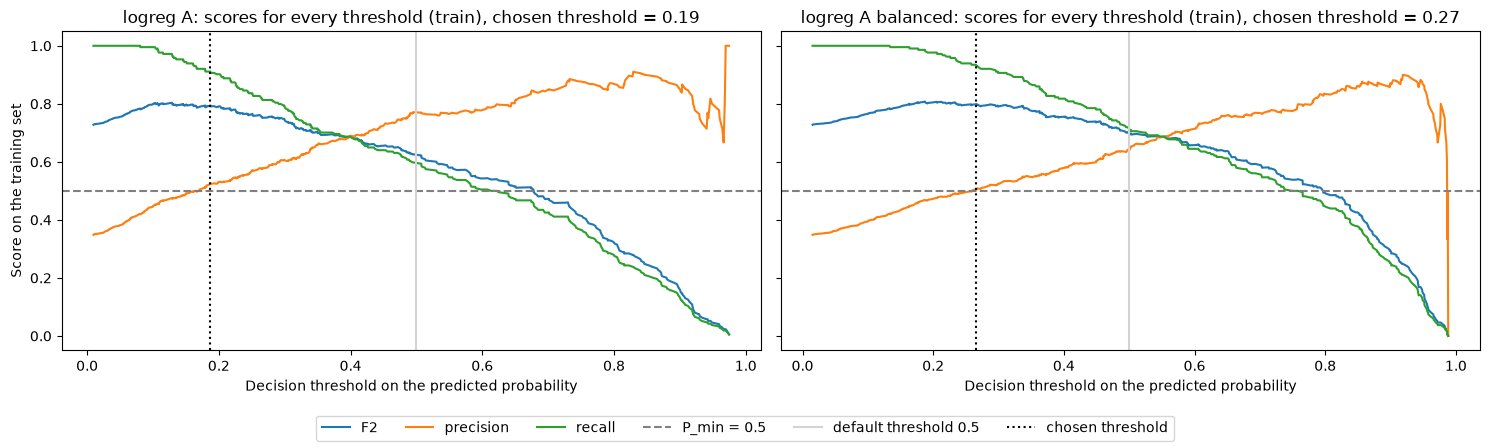

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, name in zip(axes, ["logreg A", "logreg A balanced"]):
    table = threshold_tables[name]
    for score in ["F2", "precision", "recall"]:
        ax.plot(table["threshold"], table[score], label=score)
    ax.axhline(P_MIN, color="grey", linestyle="--", label=f"P_min = {P_MIN}")
    ax.axvline(0.5, color="lightgrey", linestyle="-", label="default threshold 0.5")
    ax.axvline(THRESHOLDS[name], color="black", linestyle=":", label="chosen threshold")
    ax.set_xlabel("Decision threshold on the predicted probability")
    ax.set_title(f"{name}: scores for every threshold (train), chosen threshold = {THRESHOLDS[name]:.2f}")
axes[0].set_ylabel("Score on the training set")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=6)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

**What we see:** a lower threshold buys recall with precision; `balanced` shifts the curves to the right (0.27 instead of 0.19).

### 7c. All models on the training set

In [106]:
train_table = pd.DataFrame.from_dict(train_results, orient="index")
train_table.sort_values("F2", ascending=False).round(3)

,F2,precision,recall,accuracy,meets P_min
logreg B balanced + threshold 0.26,0.803,0.508,0.939,0.661,True
logreg B + threshold 0.16,0.801,0.504,0.939,0.656,True
logreg A balanced + threshold 0.27,0.799,0.505,0.935,0.658,True
logreg A + threshold 0.19,0.795,0.526,0.911,0.682,True
rule: glucose >= 112,0.731,0.500,0.827,0.651,True
reference: everyone has diabetes,0.728,0.349,1.000,0.349,False
logreg B balanced,0.701,0.648,0.715,0.765,True
logreg A balanced,0.695,0.639,0.710,0.759,True
logreg A (all 8 features),0.622,0.770,0.593,0.796,True
"logreg B (without Insulin, SkinThickness)",0.617,0.764,0.589,0.793,True


**What we see:** with their own threshold all four models reach F2 ≈ 0.80 and beat the rule; our pick: logreg B balanced + threshold.

## Step 8: Prepare the test set and evaluate all models
Test set cleaned with the training medians, scaled with the training scalers, thresholds from training; all models reported, no switching.

In [107]:
df_test_clean = apply_cleaning(df_test, TRAIN_MEDIANS)

assert df_test_clean.isna().sum().sum() == 0, "there are still NaNs in the test set"
assert list(df_test_clean.columns) == list(df_train_clean.columns)

X_test = df_test_clean[FEATURES]
y_test = df_test_clean[TARGET]
print("X_test:", X_test.shape, "| diabetes cases in the test set:", y_test.sum())
print("Values filled with training medians, per column:")
df_test[ZERO_MEANS_MISSING].isna().sum()

X_test: (154, 8) | diabetes cases in the test set: 54
Values filled with training medians, per column:


Glucose           1
BloodPressure    12
SkinThickness    52
Insulin          84
BMI               2
dtype: int64

One prediction function per model, with the same names as in the training table.

In [108]:
predictors = {
    "random baseline": lambda data: dummy.predict(data[FEATURES]),
    "reference: everyone has diabetes": lambda data: np.ones(len(data), dtype=int),
    f"rule: glucose >= {GLUCOSE_CUTOFF:.0f}": lambda data: rule_predict(data, GLUCOSE_CUTOFF),
    "logreg A (all 8 features)": lambda data: logreg.predict(scaler.transform(data[FEATURES_A])),
    "logreg B (without Insulin, SkinThickness)": lambda data: logreg_b.predict(scaler_b.transform(data[FEATURES_B])),
    "logreg A balanced": lambda data: logreg_balanced.predict(scaler_balanced.transform(data[FEATURES_A])),
    "logreg B balanced": lambda data: logreg_balanced_b.predict(scaler_balanced_b.transform(data[FEATURES_B])),
}
for name, (model_scaler, model, features) in candidates.items():
    predictors[f"{name} + threshold {THRESHOLDS[name]:.2f}"] = (
        lambda data, s=model_scaler, m=model, f=features, t=THRESHOLDS[name]:
            (predict_probability(s, m, data, f) >= t).astype(int)
    )

assert predictors.keys() == train_results.keys(), "the test models must match the training models"

In [109]:
CHOSEN_MODEL = f"logreg B balanced + threshold {THRESHOLDS['logreg B balanced']:.2f}"

rows = {}
for name, predict in predictors.items():
    test_scores = classification_scores(y_test, predict(df_test_clean))
    rows[name] = {
        "F2 train": train_results[name]["F2"], "F2 test": test_scores["F2"],
        "precision train": train_results[name]["precision"], "precision test": test_scores["precision"],
        "recall train": train_results[name]["recall"], "recall test": test_scores["recall"],
        "accuracy test": test_scores["accuracy"],
        "meets P_min (test)": test_scores["meets P_min"],
    }

results = pd.DataFrame.from_dict(rows, orient="index")
results["F2 train − test"] = results["F2 train"] - results["F2 test"]
results.index = [f"► {name}" if name == CHOSEN_MODEL else name for name in results.index]
results.sort_values("F2 train", ascending=False).round(3)

,F2 train,F2 test,precision train,precision test,recall train,recall test,accuracy test,meets P_min (test),F2 train − test
► logreg B balanced + threshold 0.26,0.803,0.806,0.508,0.532,0.939,0.926,0.688,True,-0.004
logreg B + threshold 0.16,0.801,0.804,0.504,0.526,0.939,0.926,0.682,True,-0.003
logreg A balanced + threshold 0.27,0.799,0.806,0.505,0.532,0.935,0.926,0.688,True,-0.008
logreg A + threshold 0.19,0.795,0.784,0.526,0.533,0.911,0.889,0.688,True,0.010
rule: glucose >= 112,0.731,0.764,0.500,0.541,0.827,0.852,0.695,True,-0.033
reference: everyone has diabetes,0.728,0.730,0.349,0.351,1.000,1.000,0.351,False,-0.002
logreg B balanced,0.701,0.681,0.648,0.603,0.715,0.704,0.734,True,0.020
logreg A balanced,0.695,0.681,0.639,0.603,0.710,0.704,0.734,True,0.014
logreg A (all 8 features),0.622,0.517,0.770,0.600,0.593,0.500,0.708,True,0.105
"logreg B (without Insulin, SkinThickness)",0.617,0.500,0.764,0.591,0.589,0.481,0.701,True,0.117


**What we see:** chosen model F2 0.81 on test (0.80 on train), precision 0.53, recall 0.93; beats the glucose rule (0.76).

### 8.1 Where does the best model still make mistakes? The confusion matrix
Rows = truth, columns = prediction; the glucose rule next to it.

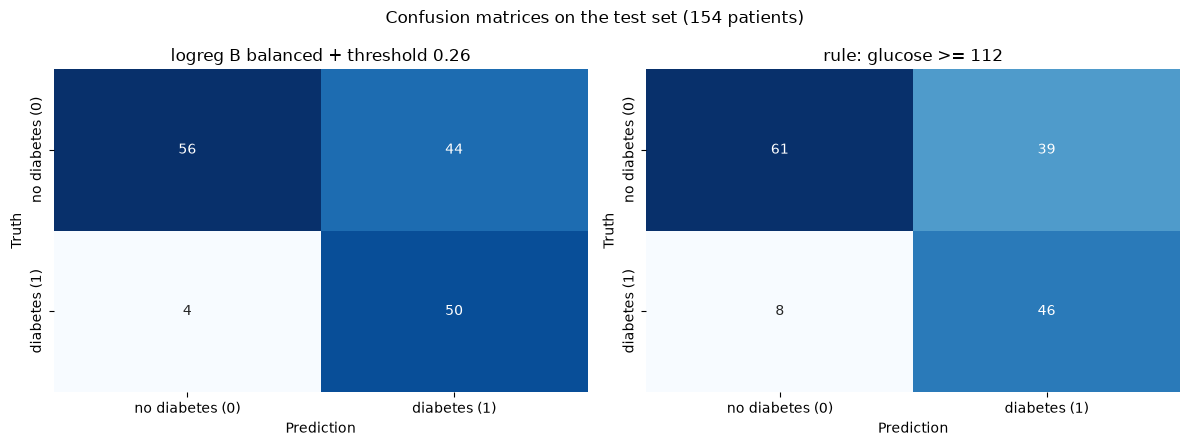

logreg B balanced + threshold 0.26: TN = 56, FP = 44, FN = 4, TP = 50
Found 50 of 54 future diabetes cases, missed 4.
44 false alarms: 44 of 100 women without diabetes would get an unnecessary check-up.


In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, name in zip(axes, [CHOSEN_MODEL, f"rule: glucose >= {GLUCOSE_CUTOFF:.0f}"]):
    matrix = confusion_matrix(y_test, predictors[name](df_test_clean))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["no diabetes (0)", "diabetes (1)"], yticklabels=["no diabetes (0)", "diabetes (1)"])
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Truth")
    ax.set_title(name)
plt.suptitle("Confusion matrices on the test set (154 patients)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, predictors[CHOSEN_MODEL](df_test_clean)).ravel()
print(f"{CHOSEN_MODEL}: TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
print(f"Found {tp} of {tp + fn} future diabetes cases, missed {fn}.")
print(f"{fp} false alarms: {fp} of {tn + fp} women without diabetes would get an unnecessary check-up.")

**What we see:** 50 of 54 future cases found, 4 missed (glucose rule: 8), 44 false alarms.

## Conclusion
Glucose is the strongest sign; BMI and insulin supported, pregnancies cannot tell yet; the model finds 93 % of future cases at precision 0.53.

In [111]:
# Your code here

